# Modules

In [1]:
import glob
from regions import Regions
from natsort import natsorted
from astropy.time import Time

from extract_EchoProfiles import *
from Pfitting_utility import *

In [2]:
%load_ext autoreload
%autoreload 2

# Read in Data

In [3]:
### Data mapping -- lists images and corresponding epochs

data_mapping = pd.read_csv('../data/mapping.txt', header=None, names=['Data_Set', 'Obs_Date', 'file_pattern'], sep='\s+')

In [4]:
### Select data set

data_set = 'Greebo'
filt = 'f444w'

dat_inds = np.where(data_mapping['Data_Set'].eq(data_set))[0]

fi_pat = data_mapping.loc[dat_inds,'file_pattern'].values

images = [glob.glob(f"../data/{data_set}/{filt}/{fi_pat[i]}*.fits")[0] for i in range(len(fi_pat))]

# Define Box Profiles

In [5]:
### Define light echo postions and profile box parameters
    # ra, dec -- center of LE location
    # pa -- position angle of profile box on sky
    # bl -- box length in arcsec
    # bw -- box width in arcsec
    # bnm -- name pattern for saving
    # ims -- some LEs are not usable across all epochs (structure gets more complicated and not usable for fitting)


## LE 1 -- arbitrary labelling different LEs
 # this LE is a slower moving one, but cleaner extraction across all epochs so good for test case for code
reg_fi = Regions.read('../data/Greebo/GreeboLE3_box.reg')
r_center = reg_fi[0].center
ra1 = r_center.ra.deg
dec1 = r_center.dec.deg
pa1 = reg_fi[0].angle.value
bl1 = reg_fi[0].height.value
bw1 = 0.1
bnm1 = 'LE1'
ims1 = images
params1 = [ra1, dec1, pa1, bl1, bw1, bnm1, ims1]

## LE 2
ra2 = 350.2627917
dec2 = 58.1918300
pa2 = 6.
bl2 = 5.0
bw2 = 0.1
bnm2 = 'LE2'
ims2 = images[:6]
params2 = [ra2, dec2, pa2, bl2, bw2, bnm2, ims2]

## LE 3
ra3 = 350.2571409
dec3 = 58.1894949
pa3 = 6.
bl3 = 5.0
bw3 = 0.1
bnm3 = 'LE3'
ims3 = images[:9]
params3 = [ra3, dec3, pa3, bl3, bw3, bnm3, ims3]

# Extraction

In [6]:
### Define selected light echo and profile box

sel_ra, sel_dec, sel_pa, sel_bl, sel_bw, sel_nm, sel_ims = params3

In [7]:
### Extract the data from the selected light echo profile box

profiles = []
for im in sel_ims:
    with NIRCamProfileExtractor(im) as extractor:
        profile = extractor.extract_profile_sky(center_ra=sel_ra, center_dec=sel_dec, length_arcsec=sel_bl, width_arcsec=sel_bw, sky_pa=sel_pa)
        profiles.append(profile)

-------------------------------
File: jw08527-o028_t007_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 231.07 degrees
Obs date: 2025-07-14
-------------------------------
-------------------------------
File: jw08527-o017_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 219.77 degrees
Obs date: 2025-07-28
-------------------------------
-------------------------------
File: jw08527-o018_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 207.73 degrees
Obs date: 2025-08-12
-------------------------------
-------------------------------
File: jw08527-o019_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 198.19 degrees
Obs date: 2025-08-23
-------------------------------
-------------------------------
File: jw08527-o020_t

-------------------------------
File: jw08527-o028_t007_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 231.07 degrees
Obs date: 2025-07-14
-------------------------------


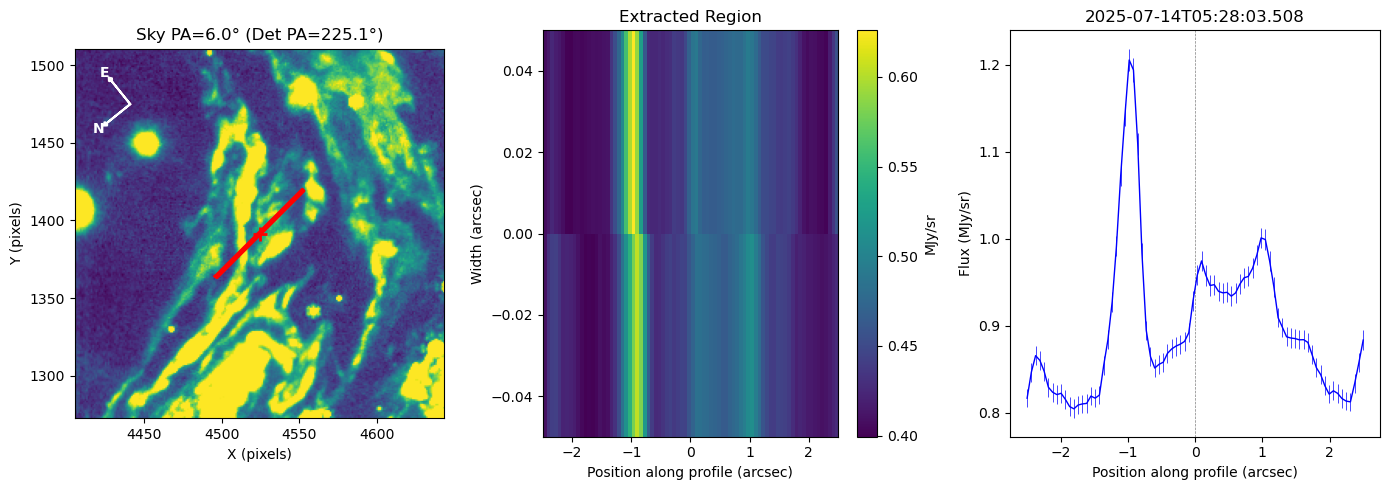

-------------------------------
File: jw08527-o017_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 219.77 degrees
Obs date: 2025-07-28
-------------------------------


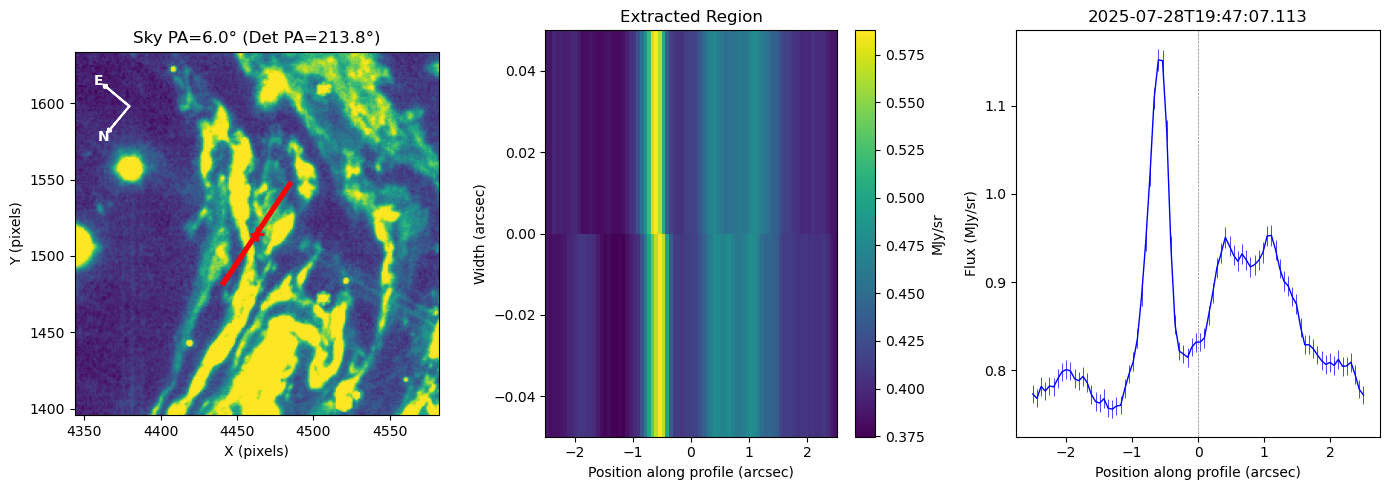

-------------------------------
File: jw08527-o018_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 207.73 degrees
Obs date: 2025-08-12
-------------------------------


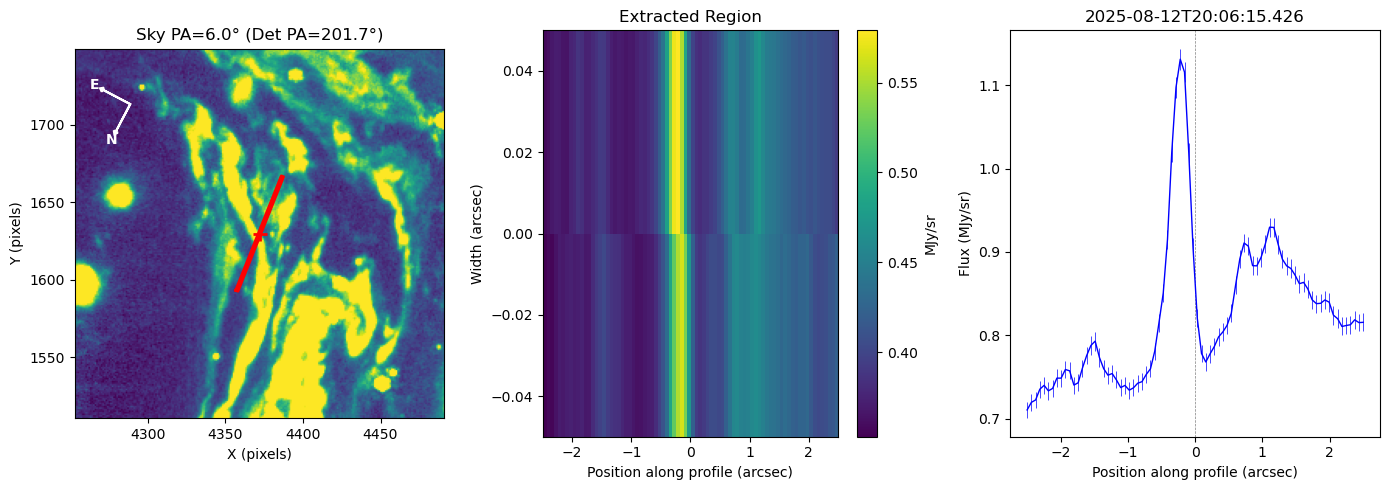

-------------------------------
File: jw08527-o019_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 198.19 degrees
Obs date: 2025-08-23
-------------------------------


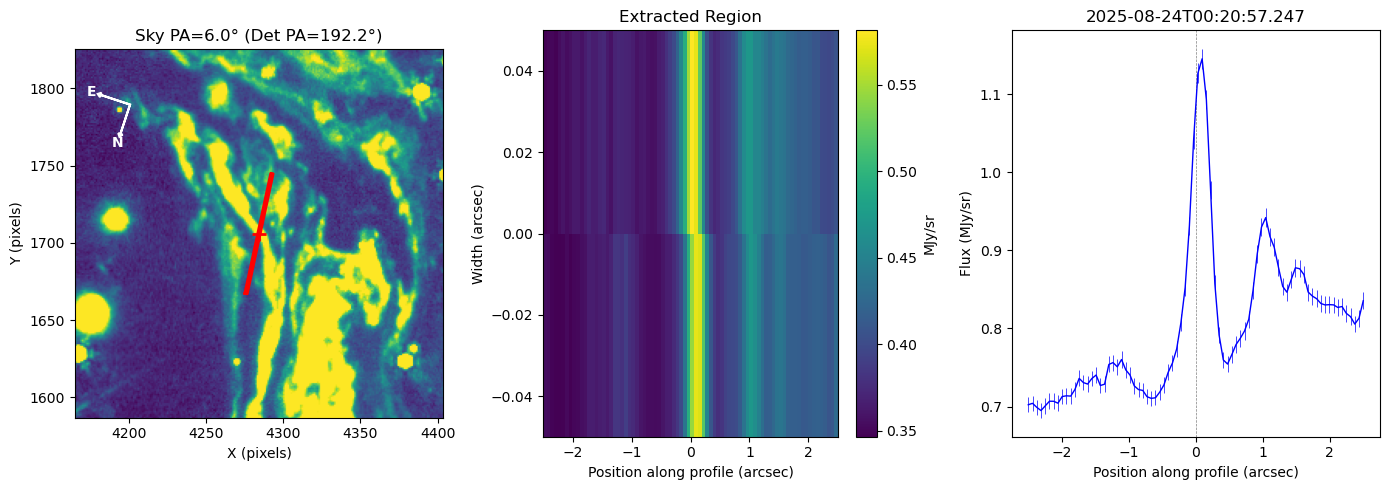

-------------------------------
File: jw08527-o020_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 184.44 degrees
Obs date: 2025-09-07
-------------------------------


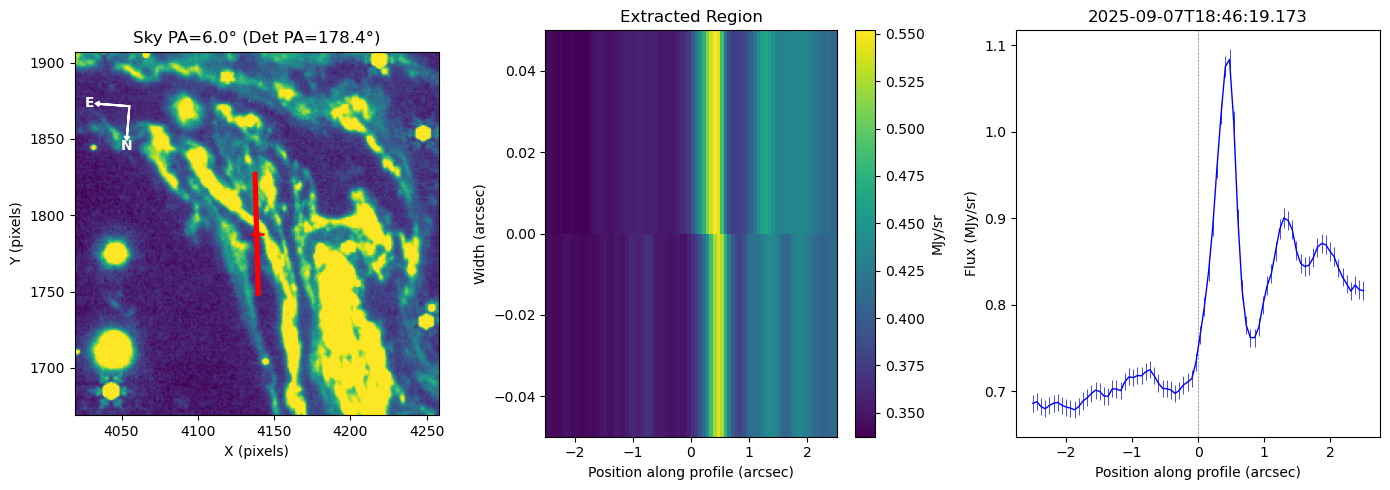

-------------------------------
File: jw08527-o021_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 168.34 degrees
Obs date: 2025-09-23
-------------------------------


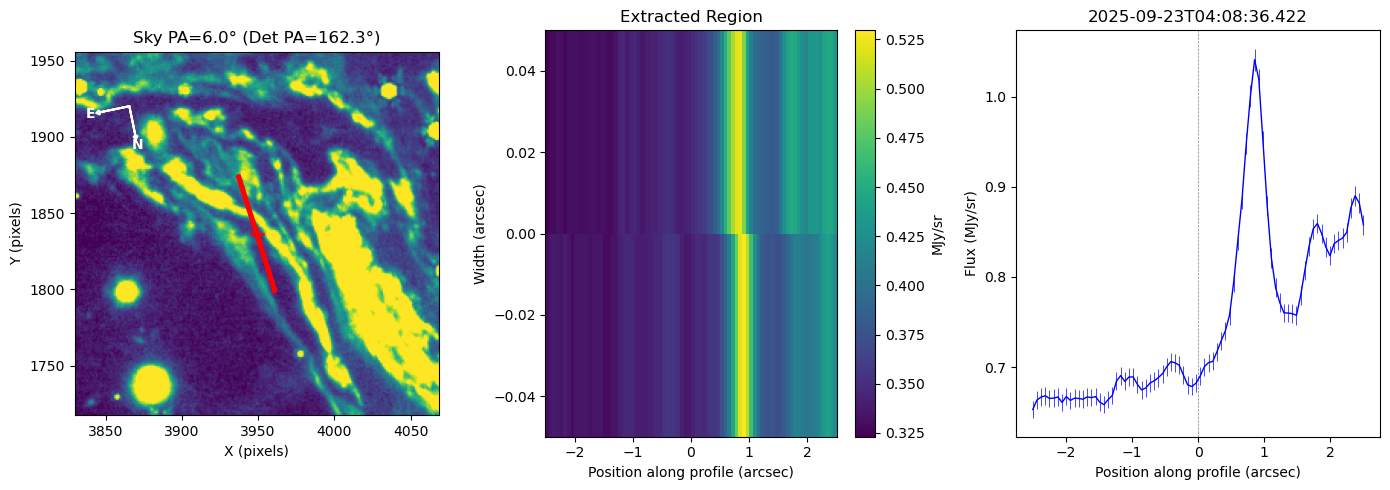

-------------------------------
File: jw08527-o022_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 152.14 degrees
Obs date: 2025-10-07
-------------------------------


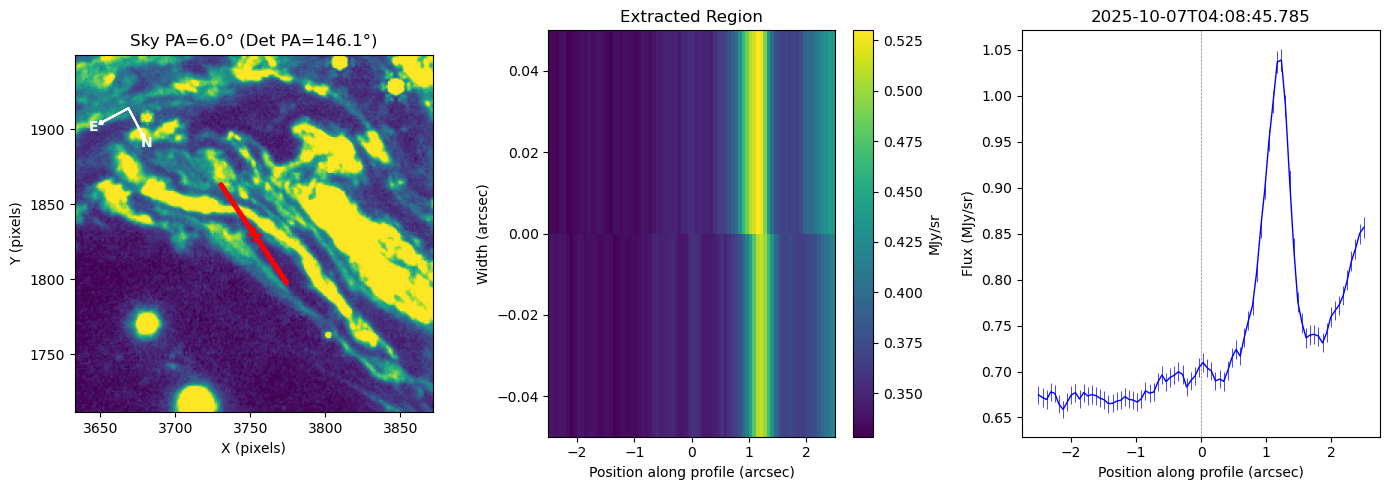

-------------------------------
File: jw08527-o052_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 146.11 degrees
Obs date: 2025-10-12
-------------------------------


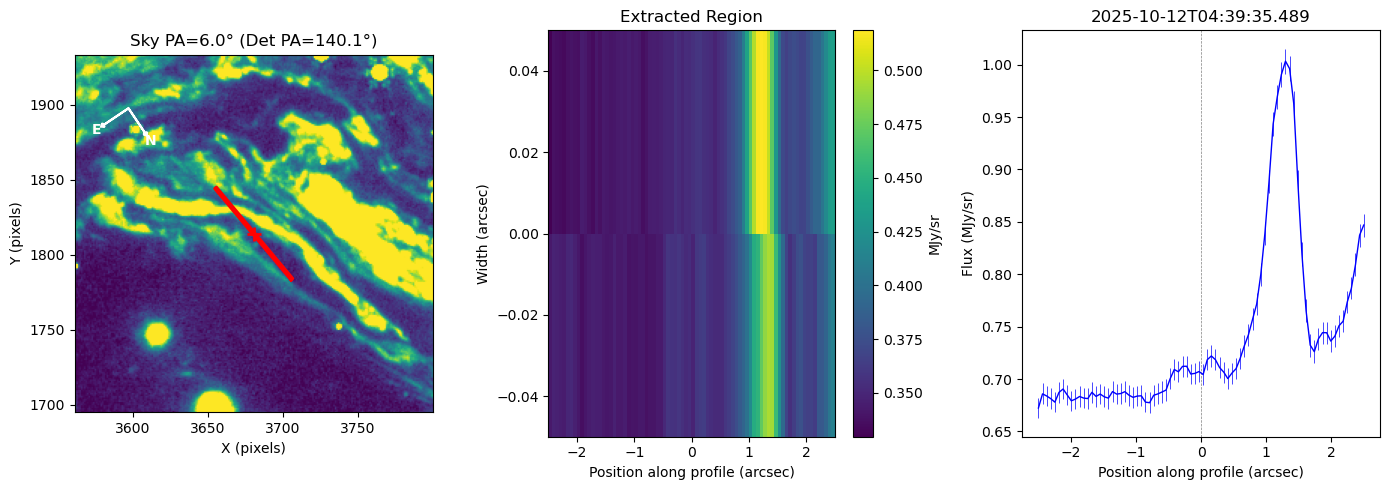

-------------------------------
File: jw08527-o023_t003_nircam_clear-f444w_i2d.fits
Filter: F444W
Image shape: (2386, 5145)
Pixel scale: 0.0629 arcsec/pixel
Roll angle: 134.18 degrees
Obs date: 2025-10-21
-------------------------------


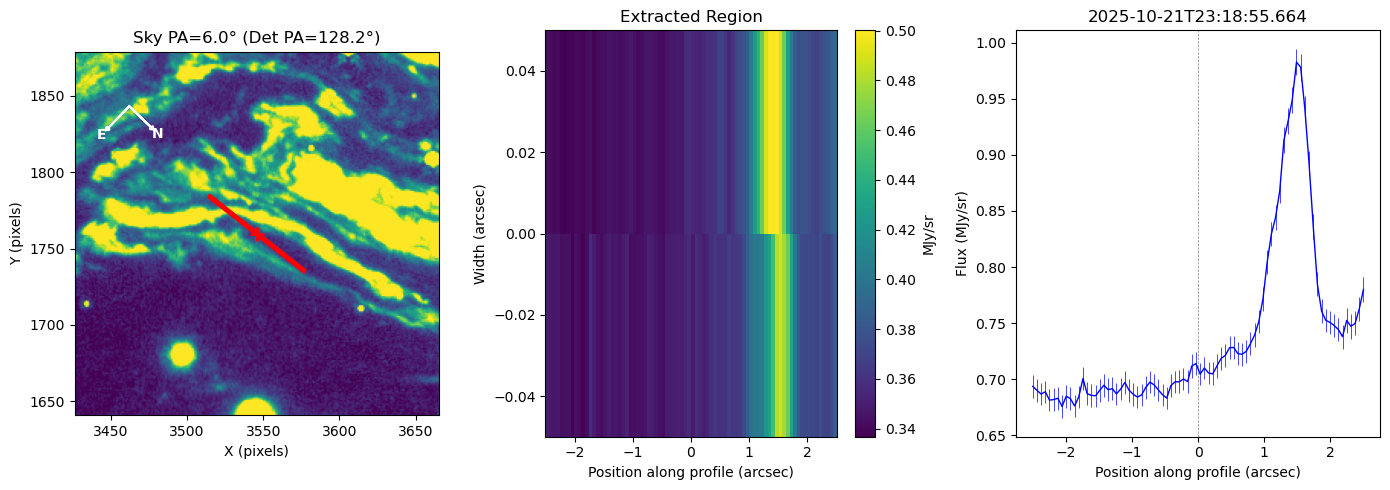

In [8]:
### Plot the extractions

for im, profile in zip(sel_ims, profiles):
    with NIRCamProfileExtractor(im) as extractor:
        extractor.plot_extraction(profile, just_show=True)
        
        fig, axes = extractor.plot_extraction(profile)
        epoch_label = profile['fits_info']['obs_date']
        epoch_label = epoch_label.partition('T')[0].replace('-','')
        fig.savefig(f"../profiles/{data_set}/{sel_nm}/{filt}/figures/extprofile_{epoch_label}.png", dpi=150, bbox_inches='tight')
        plt.close()

In [9]:
### Compare extractions across epochs

# fig, axes = plot_multi_epoch_comparison(profiles)
# plt.show()

In [10]:
### Save the profiles as fits files

for i, prof in enumerate(profiles):
    epoch_label = prof['fits_info']['obs_date']
    epoch_label = epoch_label.partition('T')[0].replace('-','')
    save_profile_fits(prof, f"../profiles/{data_set}/{sel_nm}/{filt}/data/extprofile_{epoch_label}.fits")

Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250714.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250728.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250812.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250824.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250907.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20250923.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20251007.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20251012.fits
Saved profile to ../profiles/Greebo/LE3/f444w/data/extprofile_20251021.fits


# Initial Fitting Setup

In [11]:
### Read in data

sel_nm = bnm3
pfiles = natsorted(glob.glob(f"../profiles/Greebo/{sel_nm}/{filt}/data/*.fits"))

profiles = []
data_ls = []

for pnm in pfiles:
    prof = load_profile_fits(pnm)
    profiles.append(prof)
    data = {k: prof['profile_data'][k] for k in ['xax_arcsec', 'flux', 'flux_err']}
    data['obs_date'] = Time(prof['fits_info']['obs_date'], scale='utc')
    data_df = pd.DataFrame(data)
    data_ls.append(data_df)

In [12]:
### Background estimation and creating Gaussian Processed curve

gp_ls = []

for i in range(len(data_ls)):
    # print(i)
    df = data_ls[i]

    bkgrnd_est = background_rolling_percentile(df['xax_arcsec'], df['flux'], window_size=30, percentile=15)

    df['flux_bkgsub'] = df['flux'].values - bkgrnd_est

    gp = optimized_GP(df, bkgsub=True)

    gp_ls.append(gp)

In [13]:
### Peak and fitting range selection -- manual selection by mouse click

%matplotlib qt

for i in range(len(data_ls)):
    df = data_ls[i]
    gp = gp_ls[i]
    plt.plot(gp['xax_arcsec'], gp['flux_bkgsub'], '.')
    points = plt.ginput(2)  # Click left and right bounds
    plt.close()
    
    x_min, x_max = sorted([p[0] for p in points])
    df_mask = (df['xax_arcsec'] >= x_min) & (df['xax_arcsec'] <= x_max)
    gp_mask = (gp['xax_arcsec'] >= x_min) & (gp['xax_arcsec'] <= x_max)

    df['gix_mask'] = df_mask
    gp['gix_mask'] = gp_mask
    
%matplotlib inline

In [14]:
### Check peak and range selection

# for i in range(len(data_ls)):
#     df = data_ls[i]
#     plt.scatter(df['xax_arcsec'], df['flux_bkgsub'])
#     peak_mask = np.where(df['gix_mask'].eq(True))[0]
#     plt.scatter(df['xax_arcsec'][peak_mask], df['flux_bkgsub'][peak_mask])
#     plt.show()

In [15]:
### Center data on peak

for i in range(len(data_ls)):
    df = data_ls[i]
    gp = gp_ls[i]
    df_mask = np.where(df['gix_mask'].eq(True))[0]
    gp_mask = np.where(gp['gix_mask'].eq(True))[0]

    peak_loc = gp['xax_arcsec'][gp_mask[np.argmax(gp.loc[gp_mask,'flux_bkgsub'])]]
        
    df['peak_loc'] = peak_loc
    gp['peak_loc'] = peak_loc
    
    df['xax_centered'] = df['xax_arcsec'].values - peak_loc
    gp['xax_centered'] = gp['xax_arcsec'].values - peak_loc

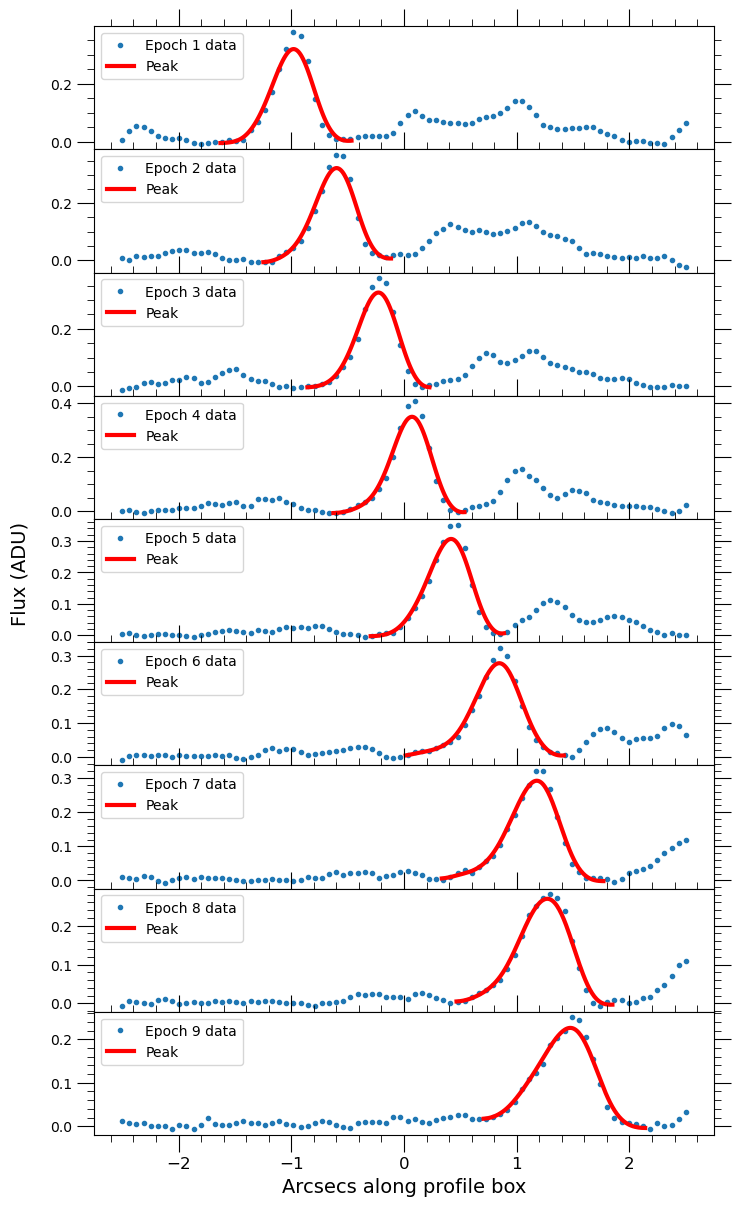

In [16]:
### Plot all data with peaks highlighted

n_sz = len(data_ls)
fig, axs = plt.subplots(n_sz, 1, dpi = 100, figsize = [8, n_sz*1.6], sharex=True)
axs = axs.flatten()

axs[-1].set_xlabel('Arcsecs along profile box', fontsize=14)

for i in range(len(axs)):
    ax = axs[i]
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=10)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    # ax.set_ylabel('Normalized Flux', fontsize = 14)
    ax.ticklabel_format(axis='both', style='plain')

    df_inds = np.where(data_ls[i]['gix_mask'].eq(True))[0]
    df_xax = data_ls[i].loc[:,'xax_arcsec']
    df_yax = data_ls[i].loc[:,'flux_bkgsub']
    # df_yax = data_ls[i].loc[:,'flux_bkgsub']

    gp_inds = np.where(gp_ls[i]['gix_mask'].eq(True))[0]
    gp_xax = gp_ls[i].loc[gp_inds,'xax_arcsec']
    gp_yax = gp_ls[i].loc[gp_inds,'flux_bkgsub']
    
    ax.errorbar(df_xax, df_yax, fmt='.', label='Epoch '+str(i+1)+' data')
    ax.errorbar(gp_xax, gp_yax, fmt='-', label='Peak', color='red', lw=3)
    # ax.axhline(y=0, ls='--', color='k')
    
    ax.legend(loc=2)

fig.supylabel('Flux (ADU)', fontsize = 14)

fig.subplots_adjust(wspace=0, hspace=0)

fig.savefig(f"../profiles/Greebo/{sel_nm}/{filt}/plots/peaks.png", bbox_inches = 'tight', dpi=100)

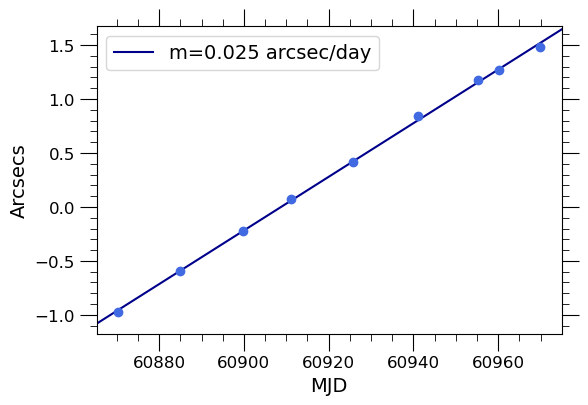

In [17]:
### Calculate apparent motion

peak_locs = [df['peak_loc'][0] for df in data_ls]
locs_epochs = [df['obs_date'][0].mjd for df in data_ls]
apmo_fit, fig_apmo, ax_apmo = get_appmotion(locs_epochs, peak_locs, None)

fig_apmo.savefig(f"../profiles/Greebo/{sel_nm}/{filt}/plots/apparent_motion.png", bbox_inches = 'tight', dpi=100)

In [18]:
### Convert arcsecs to days

apmo = apmo_fit[0][0]
apmo_err = apmo_fit[1][0]

for i in range(len(data_ls)):
    df = data_ls[i]
    gp = gp_ls[i]

    df['app_motion'] = apmo
    df['app_error'] = apmo_err
    df['xax_days'] = df['xax_centered'].values/apmo
    
    gp['app_motion'] = apmo
    gp['app_error'] = apmo_err
    gp['xax_days'] = gp['xax_centered'].values/apmo

In [19]:
### Save tables -- numbered-orederd by ascending epcoch

for i in range(len(data_ls)):
    df = data_ls[i]
    gp = gp_ls[i]

    epoch_label = df['obs_date'][0].isot
    epoch_label = epoch_label.partition('T')[0].replace('-','')
    
    df.to_csv(f"../profiles/Greebo/{sel_nm}/{filt}/tables/df_{epoch_label}.csv", index=False)
    gp.to_csv(f"../profiles/Greebo/{sel_nm}/{filt}/tables/gp_{epoch_label}.csv", index=False)